# Lab 2 - Ensemble methods

In this notebook, you will employ **boosting** and **stacking** to combine multiple models into a (hopefully) better one. Here's what you will do.
 - [Part 1](#1.-Feature-engineering) - Feature engineering
 - [Part 2](#2.-Baseline-models) - Baseline models
 - [Part 3](#3.-Gradient-boosting) - Gradient boosting
 - [Part 4](#4.-Stacking) - Stacking

Here is the list of packages that you will need during this assignment.
- [numpy](www.numpy.org) is the fundamental package for scientific computing with Python.
- [scipy](https://www.scipy.org) provides many numerical routines for scientific computing.
- [sklearn](http://scikit-learn.org/stable/) provides simple and efficient tools for data analysis and machine learning.
- [pandas](https://pandas.pydata.org) is a library providing easy-to-use data structures and data analysis tools.
- [matplotlib](http://matplotlib.org) is a library for plotting graphs in Python.
- [seaborn](https://seaborn.pydata.org/index.html) provides a high-level interface for drawing attractive statistical graphics.

*Make sure to run the following cell.*

In [274]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm, skew

from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.metrics import r2_score
from sklearn.base import clone

---

# 1. Feature engineering

The Ames Housing dataset describes the sale of individual residential property in Ames, Iowa from 2006 to 2010. It is a modernized and expanded version of the often cited Boston Housing dataset. More information can be found [here](https://ww2.amstat.org/publications/jse/v19n3/decock.pdf).

The Ames dataset contains 2930 observations and 80 variables (plus 2 observation identifiers) of different type: 
 - 23 nominal
 - 23 ordinal
 - 14 discrete 
 - 20 numerical.
 
The goal is to build a regression model for the variable `SalePrice`. Let's give a quick look at the data.

In [275]:
data = pd.read_csv("lab02_data/AmesHousing.csv", sep=";")

data.head()

,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


It seems that the dataset needs some feature engeneering. Let's start with a simple task.


### Exercise 

> **Remove the columns `Order` and `PID` from the dataset.**

*Hint:* Use the pandas function `drop()`.

In [276]:
data = data.drop(columns=['Order', 'PID'])

print("Dataset size: " + str(data.shape))

data.head()

Dataset size: (2930, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [277]:
# If this cell raises an error, your solution is *NOT* correct

assert data.shape == (2930,80)

## 1.1 Missing data 

Missing data occur when no data value is stored for a variable in an observation. This is a common occurrence in real-world datasets, and it can have a significant effect on the conclusions that can be drawn from the data. Understanding the reasons why data are missing is important to correctly handle the remaining data. 

The following code computes the amount of missing data for each variable in the dataset.

In [278]:
# missing values
total = data.isnull().sum().sort_values(ascending=False)

# show
pd.DataFrame(data={'Missing': total}).head(30)

,Missing
PoolQC,2917
MiscFeature,2824
Alley,2732
Fence,2358
FireplaceQu,1422
LotFrontage,490
GarageCond,159
GarageFinish,159
GarageYrBlt,159
GarageQual,159


By reading the data description, we can understand that missing values actually have a precise meaning for some features:
 - **PoolQC**: NA means *No Pool*.
 - **MiscFeature**: NA means *No Misc Feature*.
 - **Alley**: : NA means *No Alley*.
 - **Fence**: : NA means *No Fence*.
 - **FireplaceQu** : NA means *No Fireplace*.
 - **GarageXXX**: NA means *No Garage*.
 - **BsmtXXX**: NA means *No Basement*.
 - **MasVnrXXX**: NA means *No masonry veneer*.

For other features, missing data can be replaced with "default" values:
 - **LotFrontage** : Since the area of each street connected to the house property most likely have a similar area to other houses in its neighborhood , we can fill in missing values by the median `LotFrontage` of the neighborhood.
 - **Electrical** : It has one NA value. Since this feature has mostly 'SBrkr', we can set that for the missing value.

### Exercise 

> **Replace missing data with the appropriate "default" values.**
> 
> - Use the string "None" in `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`.
>     
> - Use the string "None" in `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`.
>  
> - Use the value 0 in `GarageYrBlt`, `GarageArea`, `GarageCars`.
> 
> - Use the string "None" in `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`.
>     
> - Use the value 0 in `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath`.
> 
> - Use the string "None" in `MasVnrType` and the value 0 in `MasVnrArea`.
> 
> - Use the most common value in `Electrical`.
   
*Hint:* Use the pandas function `fillna()` to replace NA with a given value; use the pandas function `mode()` to find the most common value of a column.

In [279]:
none_features = ('PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 
                 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType')
zero_features = ('GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea')
cst_feature = 'Electrical'

for feat in none_features:
    data[feat] = data[feat].fillna("None")
    
for feat in zero_features:
    data[feat] = data[feat].fillna(0)
    
data[cst_feature] = data[cst_feature].fillna( data[cst_feature].mode()[0] )

total = data.isnull().sum().sort_values(ascending=False)
pd.DataFrame(data={'Missing': total}).head(2)

,Missing
LotFrontage,490
MSSubClass,0


In [280]:
# If this cell raises an error, your solution is *NOT* correct

for col in (none_features + zero_features + (cst_feature,)):
    assert data[col].isnull().sum() == 0

### Exercise

> **Replace the missing data in `LotFrontage` with the following procedure.**
> - Group the values in `LotFrontage` having the same `neighborhood`.
> - Compute the median value of `LotFrontage` on each group separately.
> - For each group, replace the missing values in `LotFrontage` with the corresponding median.
  
*Hint:* Use the pandas function `groupby()` to group observations by the value of a column, and the function `transform()` to manipulate each group separately. See this [tutorial](http://pbpython.com/pandas_transform.html) for more information about groups in pandas.

In [281]:
data['LotFrontage'] = data.groupby('Neighborhood')['LotFrontage'].transform( lambda x: x.fillna( x.median(skipna=True) ) )
total = data.isnull().sum().sort_values(ascending=False)
pd.DataFrame(data={'Missing': total}).head(2)

C:\Users\Franc\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Franc\anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Missing
LotFrontage,3
MSSubClass,0


In [282]:
# If this cell raises an error, your solution is *NOT* correct

assert data['LotFrontage'].isnull().sum() == 3

With the previous approach, we weren't able to determine `LotFrontage` for 3 houses, as all the observations in the corresponding neighborhoods have missing values in `LotFrontage`. To avoid the risk of introducing a bias in the data, we decide to drop these observations.

In [283]:
mask = data['Neighborhood'].isin(["Landmrk","GrnHill"])
data = data[~mask]

print("Missing values: " + str(data.isnull().sum().sum()))
print("Dataset shape: " + str(data.shape))

Missing values: 0
Dataset shape: (2927, 80)


## 1.2 Correlation matrix

Now, it's time to analyze the correlation between `SalePrice` and the other variables.

C:\Users\Franc\AppData\Local\Temp\ipykernel_4688\3854032639.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = data.corr()


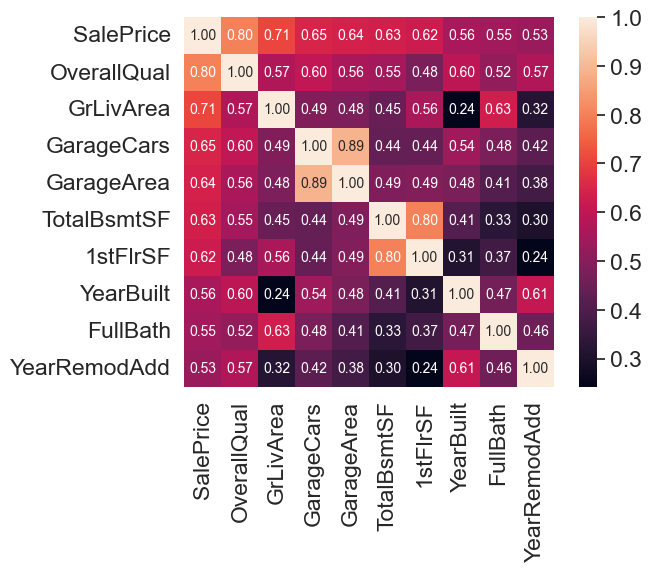

In [284]:
# correlation matrix
corrmat = data.corr()

# variables for heatmap
k = 10 
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = corrmat[cols].loc[cols]

# show
sns.set(font_scale=1.5)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

From the top-10 correlation matrix, we can deduce that:

- `OverallQual`, `GrLivArea` and `TotalBsmtSF` are strongly correlated with `SalePrice`.
- `GarageCars` is correlated to `GarageArea`. This seems reasonable, as the number of cars fitting into a garage is proportional to the garage area.
- `TotalBsmtSF` is correlated to `1stFlrSF`. This seems reasonable, as the floors of an house are usually the same size.

Now, let's proceed to the scatter plots between `SalePrice` and the most correlated variables.

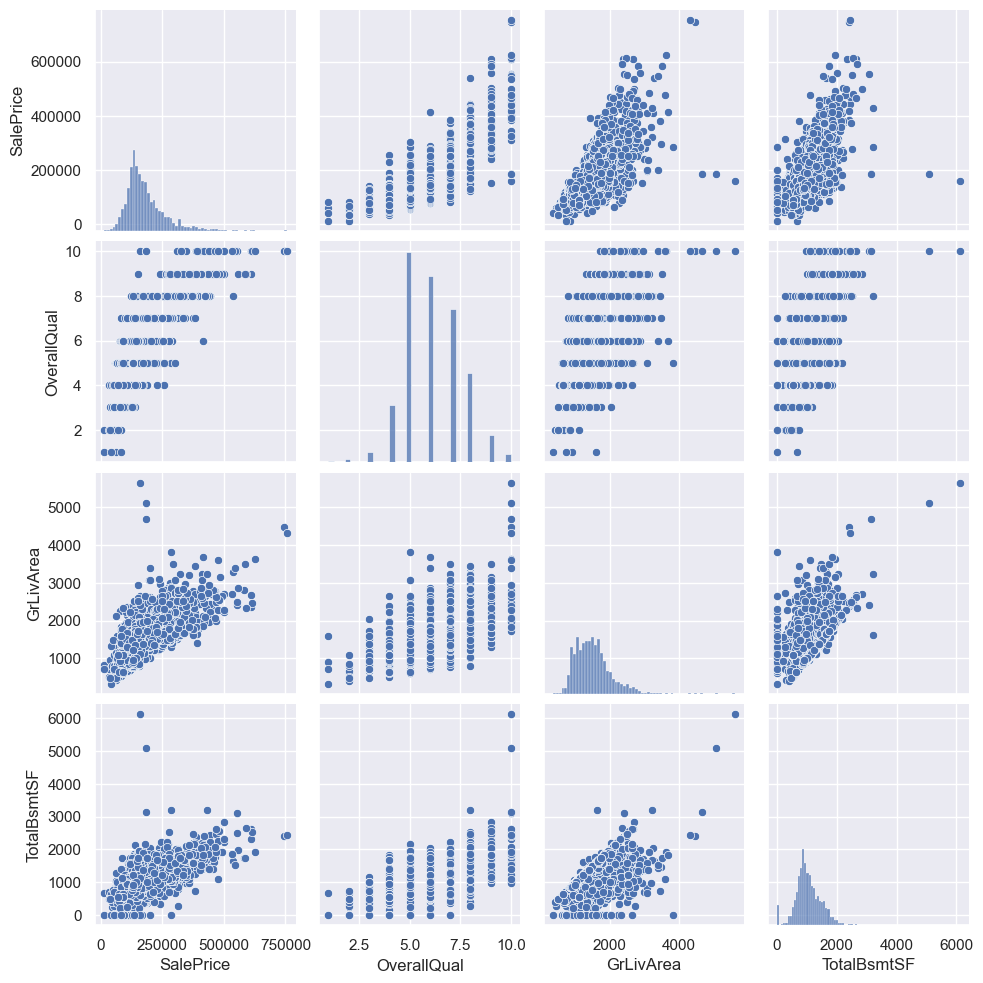

In [285]:
sns.set()

cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF']
sns.pairplot(data[cols], height = 2.5)
plt.show()

The variables `OverallQual`, `GrLivArea` and `TotalBsmtSF` seem to be linearly related with `SalePrice`. The relationships are positive, which means that as one variable increases, the other also increases.

Since area-related features are very important to determine house prices, we are going to craft a new feature that indicates the total area of basement and above ground living space.

### Exercise

> **Add a new feature `TotalSF` given by the sum of `GrLivArea` and `TotalBsmtSF`.**

In [286]:
new_feature = 'TotalSF'

data[new_feature] = data['GrLivArea'] + data['TotalBsmtSF']

print("Dataset shape: " + str(data.shape))

Dataset shape: (2927, 81)


In [287]:
# If this cell raises an error, your solution is *NOT* correct

assert data.shape == (2927, 81)
assert 'TotalSF' in data.columns

## 1.3 Outliers

Outliers are something that we should be aware of. Why? Because outliers can markedly affect our models, and can be a valuable source of information, providing us insights about specific behaviours. Outlier handling is a complex subject. Here, we'll just do a quick analysis through the scatter plots.

Let's plot `SalePrice` versus `GrLivArea`, so as to easily spot any large houses that sold for really cheap.

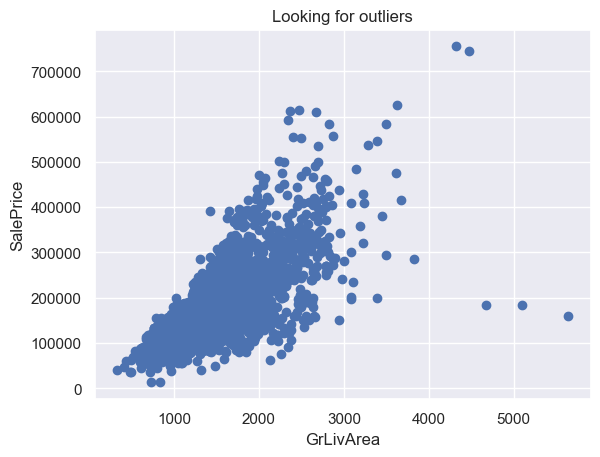

In [288]:
plt.scatter(data.GrLivArea, data.SalePrice)
plt.title("Looking for outliers")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

Here's what we can deduce from the scatterplot.

- The three values with bigger `GrLivArea` seem strange and they are not following the crowd. Maybe they refer to agricultural area and that could explain the low price. Even though we are not sure about this, it seems that these points are not representative of the typical case. Therefore, we'll define them as outliers and delete them.
 
- The two observations in the top of the plot (above 700'000) are also suspect. They look like two special cases, however they seem to be following the trend. For that reason, we will keep them.

Outliers removal is not always safe. The points that we have decided to delete are very huge and really bad (extremely large areas for very low prices). There are probably others outliers in the training data. However, removing all of them may affect badly our models if ever there were also outliers in new data. That's why, instead of removing them all, we will just manage to make some of our models robust on them. 

### Exercise

> **Remove the outliers in which `SalePrice` is less than 300'000 and `GrLivArea` is greater than 4'000.**

In [290]:
data.drop(data[(data['SalePrice'] < 300000) & (data['GrLivArea'] > 4000)].index, inplace=True)
print("Dataset shape: " + str(data.shape))

Dataset shape: (2924, 81)


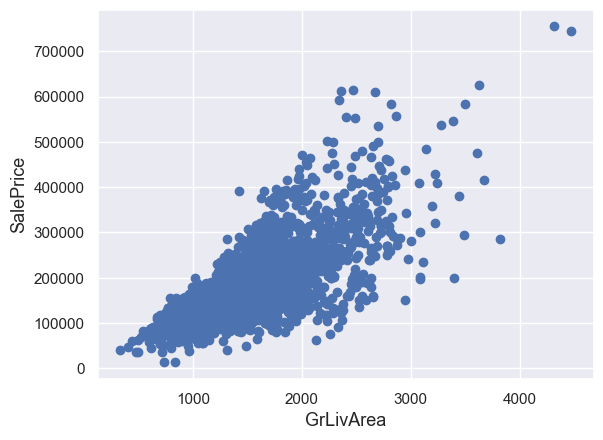

In [291]:
fig, ax = plt.subplots()
ax.scatter(data['GrLivArea'], data['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

In [292]:
# If this cell raises an error, your solution is *NOT* correct

assert data.shape == (2924, 81)

## 1.4 Categorical variables

The dataset contains different types of variable.
 - **Nominal** - This variable can take a fixed number of values. 
 - **Ordinal** - This variable can take a fixed number of values, and such values have a logical order.
 - **Discrete** - This variable can take any integer value.
 - **Numerical** - This variable can take any numerical value.

Let's start by grouping the variables according to their type.

In [293]:
nominal = ['MSSubClass', 'MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 
           'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
           'Heating', 'CentralAir', 'Electrical', 'GarageType', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition'] 
           
ordinal = ['LotShape', 'Utilities', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 
           'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 
           'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence']
           
discrete = ['YearBuilt', 'YearRemodAdd', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 
            'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'YrSold']

Ordinal variables are converted into discrete features.

In [294]:
for col in ordinal:
    v = list(data[col].values)
    data[col] = LabelEncoder().fit_transform(v)

Nominal variables are converted into binary features.

In [295]:
# cast to string
for col in nominal:
    data[col] = data[col].apply(str)

# convert to binary features
data = pd.get_dummies(data)

In [296]:
data.head()

,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_New,SaleType_Oth,SaleType_VWD,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,141.0,31770,0,0,0,5,4,1960,1960,112.0,...,0,0,0,1,0,0,0,0,1,0
1,80.0,11622,3,0,0,4,5,1961,1961,0.0,...,0,0,0,1,0,0,0,0,1,0
2,81.0,14267,0,0,0,5,5,1958,1958,108.0,...,0,0,0,1,0,0,0,0,1,0
3,93.0,11160,3,0,0,6,4,1968,1968,0.0,...,0,0,0,1,0,0,0,0,1,0
4,74.0,13830,0,0,0,4,4,1997,1998,0.0,...,0,0,0,1,0,0,0,0,1,0


## 1.5 Dataset split

Finally, we can split the available data in train and test sets.

In [297]:
y = np.array(data['SalePrice'])
X = np.array(data.drop('SalePrice', axis=1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

---

# 2. Baseline models

There exist many different approaches to deal with regression. In this notebook, you'll consider some of the models available in [scikit-learn](http://scikit-learn.org/stable/):
 - Linear regression
 - Regularized regression
 - Random forest.

## 2.1 Linear regression

Let's start with linear regression, which is the simplest model we could think of. The following code performs two steps.
 - The model is fit to the train set.
 - The performance is evaluated on the test set.
 
By default, the metric used to evaluate linear regression is the $R^2$ score. The best possible score is 1, and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of the target variable, disregarding the input features, would get a score of 0.

In [298]:
# model
linreg = LinearRegression()

# train
linreg.fit(X_train, y_train)

# test
score = linreg.score(X_test, y_test)
    
print('Linear regression: {:.4f}'.format(score))

Linear regression: 0.9126


To gain insight into the learned model, we can visualize the residual plot.

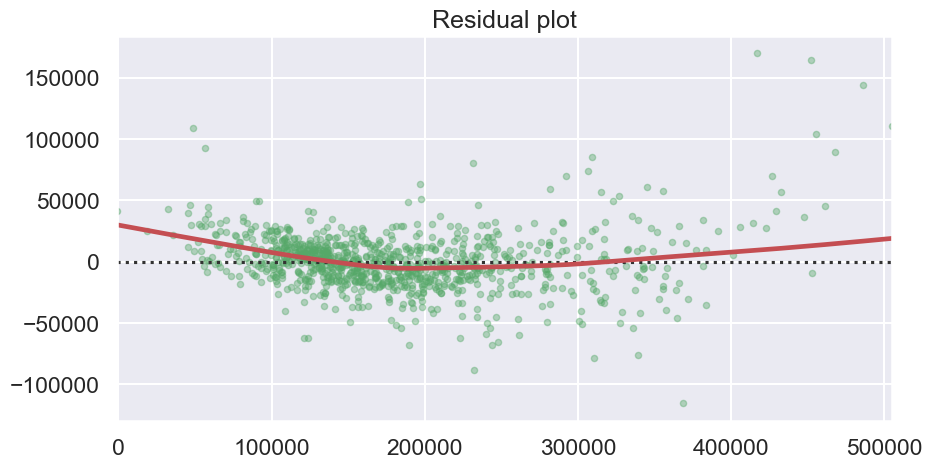

In [300]:
sns.set_context("talk")

plt.figure(figsize=(10,5))
sns.residplot(x=linreg.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

We can observe that the residuals are **not** uniformely distributed around the zero (the red line is u-shaped). This is a clear indication that there is a **nonlinear** relationship between the target variable `SalePrice` and the other variables. To figure out what kind of nonlinearity it could be, we need to go deep and understand how `SalePrice` complies with the statistical assumptions that enable us to apply linear regression. The main assumption that we should test is **normality**. In this notebook, we'll just check univariate normality by looking at:
 - **Histogram**, which tells us about kurtosis and skewness.
 - **Normal probability plot**, in which data should closely follow the diagonal that represents the normal distribution.

C:\Users\Franc\AppData\Local\Temp\ipykernel_4688\4218364359.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['SalePrice']);


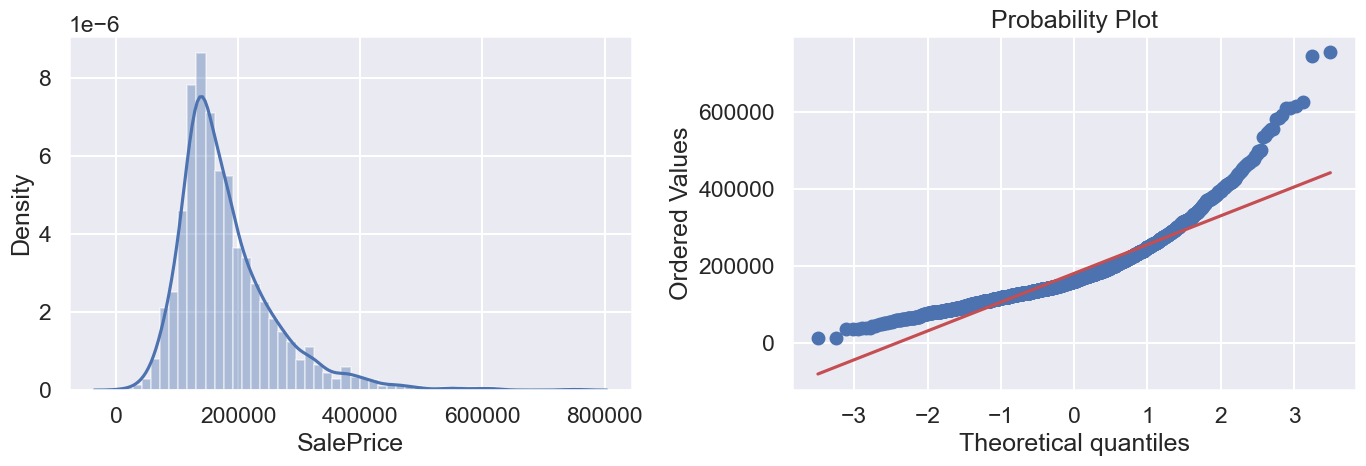

In [301]:
fig = plt.figure(figsize=(14,5), tight_layout=True)
fig.add_subplot(121)
#sns.histplot(data['SalePrice']);
sns.distplot(data['SalePrice']);
fig.add_subplot(122)
res = stats.probplot(data['SalePrice'], plot=plt)

We can see that the distribution of `SalePrice` deviates from the normal distribution and has positive skewness. A simple data transformation can solve the problem. This is one of the awesome things you can learn in statistical books: in case of positive skewness, a **logarithm** transformation usually works well. Here's how such a transformation works:

 - Train the model on the transformed target variable `LogSalePrice = log(SalePrice + 1)`.
 
 - Then, revert to the actual prediction using the formula `y = exp(LogSalePrice) - 1`.
 
Scikit-learn provides the class `TransformedTargetRegressor` to apply a transformation of the target variable before training a regression model. The code below implements the logarithm transformation (with the numerically robust functions `log1p` and `expm1`). You can use this function with any regression model.

In [302]:
def log_target(model):
    """
    The input model is "wrapped" into a logarithm transformation. The returned model works as follows:
     - '.fit(X, y)' transforms the target variable 'y' into 'z = log(y+1)' and then call `model.fit(X, z)`
     - '.predict(X) calls 'z = model.predict(X)' and then return 'exp(z)-1'
    """
    return TransformedTargetRegressor(model, func=np.log1p, inverse_func=np.expm1)

### Exercise

> **Learn a linear regressor on the train set, and test its performance on the test set. However, you must do this using a linear model wrapped into a logarithm transformation.**

> *Hint:* Check the scikit-learn [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), and specifically the methods `.fit()` and `.score()`.

In [304]:
# model with log-transformed target
linreg = log_target(LinearRegression())

# train
linreg.fit(X_train, y_train)

# test
score = linreg.score(X_test, y_test) # YOUR CODE HERE
    
# show
print('Linear regression: {:.4f}'.format(score))

Linear regression: 0.9403


In [305]:
# If this cell raises an error, your solution is *NOT* correct

np.testing.assert_almost_equal(score, 0.9403, decimal=3)

Let's look again at the residual plot. From the figure, we can see that the residuals are now regularly distributed around the zero. Hurrah!

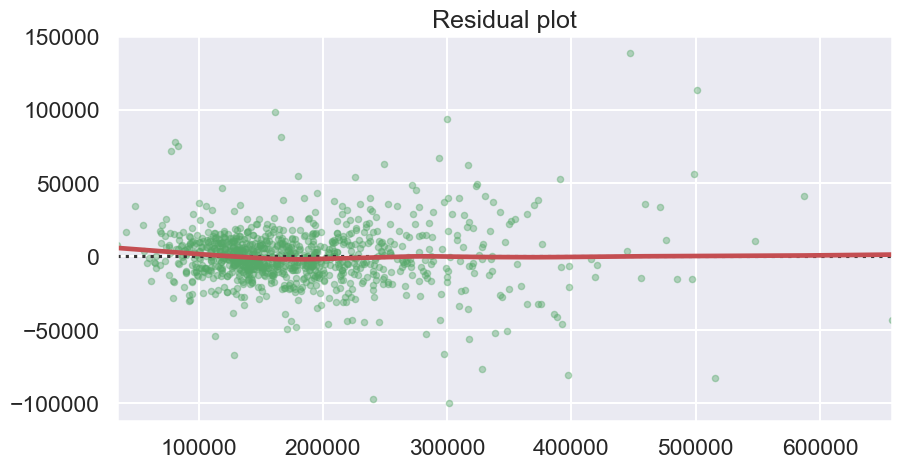

In [306]:
plt.figure(figsize=(10,5))
sns.residplot(x=linreg.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

## 2.2 Regularized regression

Other approaches worth exploring are ridge regression, lasso, and elastic net. They are all linear regression models, differing from each other in the regularization term (used to reduce the risk of over-fitting).
 - **Ridge** - L2 regularization.
 - **Lasso** - L1 regularization.
 - **Elastic net** - Both.

Regularization works best when the data are normalized. The code below uses the Scikit-Learn method `make_pipeline` to define a pipeline in which the data are properly normalized before training and testing.

In [308]:
ridge = make_pipeline(RobustScaler(), log_target(Ridge(random_state=42)))
lasso = make_pipeline(RobustScaler(), log_target(Lasso(random_state=42)))
elnet = make_pipeline(RobustScaler(), log_target(ElasticNet(random_state=42)))

models = (ridge, lasso, elnet)
names  = ('Ridge', 'Lasso', 'Elnet')

for clf, name in zip(models, names):
    
    # train
    clf.fit(X_train, y_train)
    
    # test
    score = clf.score(X_test, y_test)
    
    # show
    print('{:s}: {:.4f}'.format(name, score))

Ridge: 0.9447
Lasso: 0.0024
Elnet: 0.0278


You can see that the performances of lasso and elastic net are not satisfactory, as also confirmed in the figure below. This happens because such models depend on hyper-parameters that control how much regularization is applied during training. In order to find the hyper-parameters leading to the best performance, you can use cross-validation. 

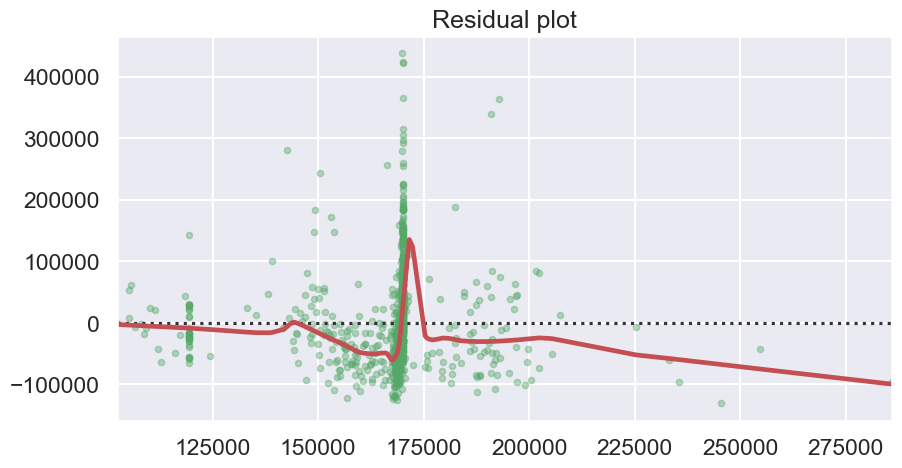

In [309]:
plt.figure(figsize=(10,5))
sns.residplot(x=elnet.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

### Exercise 

> **Find the best hyper-parameters via cross-validation. You are only allowed to use the train set.**
 
*Hint:* The following table reports the candidate values that you should test out with cross-validation.

| Model | Hyper-parameter | Values |
|:-----:|:---------------:|:--------|
| *Ridge* | alpha | 1, 5, 10, 15, 30, 50
| *Lasso* | alpha | 0.0001, 0.0005, 0.001, 0.005, 0.01
| *Elastic net* | alpha | 0.0001, 0.0005, 0.001, 0.005, 0.01
| *Elastic net* | l1_ratio | 0.2, 0.4, 0.6, 0.8, 1

In [312]:
ridge_alphas = (1, 5, 10, 15, 30, 50)  # TODO: Add candidate values
lasso_alphas = (0.0001, 0.0005, 0.001, 0.005, 0.01)  # TODO: Add candidate values
elnet_alphas = (0.0001, 0.0005, 0.001, 0.005, 0.01)  # TODO: Add candidate values
elnet_l1     = (0.2, 0.4, 0.6, 0.8, 1)  # TODO: Add candidate values

# cross-validation strategy
cv = KFold(n_splits=5)

# models
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=cv)
lasso_cv = LassoCV(alphas=lasso_alphas, cv=cv, random_state=42)
elnet_cv = ElasticNetCV(alphas=elnet_alphas, l1_ratio=elnet_l1, max_iter=5000, cv=cv, random_state=42)

# pipelines
ridge = make_pipeline(RobustScaler(), log_target(ridge_cv))
lasso = make_pipeline(RobustScaler(), log_target(lasso_cv))
elnet = make_pipeline(RobustScaler(), log_target(elnet_cv))

# train
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elnet.fit(X_train, y_train)

# score
ridge_score = ridge.score(X_test,y_test)
lasso_score = lasso.score(X_test,y_test)
elnet_score = elnet.score(X_test,y_test)

# print
print('Ridge: {:.4f}'.format(ridge_score))
print('Lasso: {:.4f}'.format(lasso_score))
print('Elnet: {:.4f}'.format(elnet_score))
print('-----')
print('Best hyper-params (ridge): alpha={:2.2f}'.format(ridge[-1].regressor_.alpha_))
print('Best hyper-params (lasso): alpha={:2.4f}'.format(lasso[-1].regressor_.alpha_))
print('Best hyper-params (elnet): alpha={:2.4f}, l1_ratio={:2.2f}'.format(
    elnet[-1].regressor_.alpha_, elnet[-1].regressor_.l1_ratio_))

C:\Users\Franc\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:634: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.7004274970484188, tolerance: 0.02566911595800312
  model = cd_fast.enet_coordinate_descent_gram(


Ridge: 0.9465
Lasso: 0.9452
Elnet: 0.9456
-----
Best hyper-params (ridge): alpha=15.00
Best hyper-params (lasso): alpha=0.0005
Best hyper-params (elnet): alpha=0.0010, l1_ratio=0.40


In [313]:
# If this cell raises an error, your solution is *NOT* correct

np.testing.assert_almost_equal(ridge_score, 0.9464, decimal=3)
np.testing.assert_almost_equal(lasso_score, 0.9452, decimal=3)
np.testing.assert_almost_equal(elnet_score, 0.9456, decimal=3)

Let's check the residual plot of elastic net.

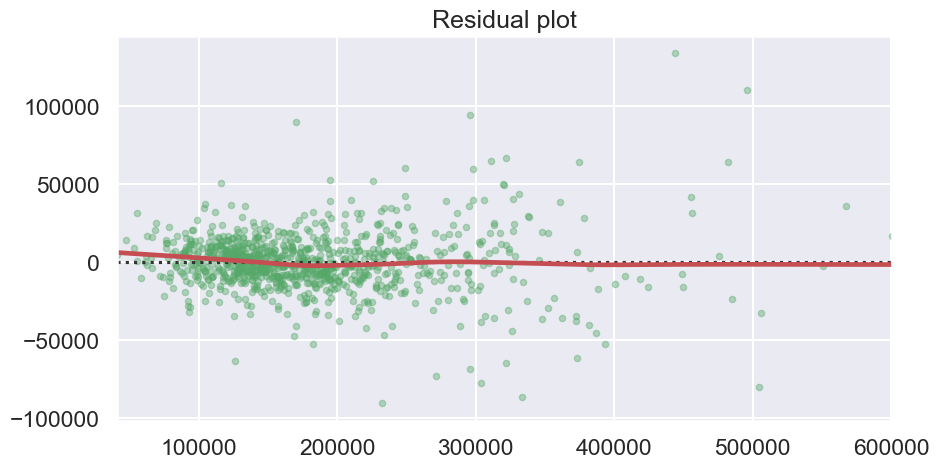

In [314]:
plt.figure(figsize=(10,5))
sns.residplot(x=elnet.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

## 2.3 Random forest

In the realm of nonlinear models, random forest is one of the most interesting techniques. The idea behind it is to build several decision trees independently, and then to average their predictions. In particular, each tree is learned from bootstrapped observations, using a random subset of the features at each node split. As a result of this randomness, the combined trees yield a prediction model that is usually better than any of the individual tree.

Random forest depends on the following hyper-parameters:
 - `n_estimators` - The number of trees in the forest.
 - `max_depth` - The maximum depth of each individual tree.
 - `max_features` - The number of features to consider when looking for the best split.
 - `min_samples_leaf` - The minimum number of samples required to be at a leaf node.

### Exercise

> **Find the best hyper-parameters via cross-validation. You are only allowed to use the train set.**
 
*Hint:* The following table reports the candidate values that you should test out with cross-validation.


| Hyper-parameter | Values |
|:---------------:|:--------|
| n_estimators | 60, 70, 80, 90, 100
| max_features | 0.2, 0.4, 0.6, 0.8, 1
| max_depth | None
| min_samples_leaf | 1

In [323]:
### YOUR CODE HERE ### 
params_grid = { 
    "n_estimators": [60, 70, 80, 90, 100],
    "max_features": [0.2, 0.4, 0.6, 0.8, 1],
    "min_samples_leaf": [1, 2]
    # TODO: add candidate values
                          # TODO: add the other parameters and their candidate values
}


# cross-validation strategy
cv = KFold(n_splits=5)

# random forest
forest = RandomForestRegressor(random_state=42)

# hyper-parameter search
forest_cv = GridSearchCV(forest, params_grid, cv=cv, n_jobs=4)
forest_cv.fit(X_train, y_train)

# best score
forest_score = forest_cv.score(X_test, y_test)

# recap
print('Random forest: {:.4f}'.format(forest_score))
print('-----')
print('Best hyper-params: ' + str(forest_cv.best_params_))

Random forest: 0.9350
-----
Best hyper-params: {'max_features': 0.4, 'min_samples_leaf': 1, 'n_estimators': 80}


In [324]:
# If this cell raises an error, your solution is *NOT* correct

np.testing.assert_almost_equal(forest_score, 0.9350, decimal=3)

Let's check the residual plot.

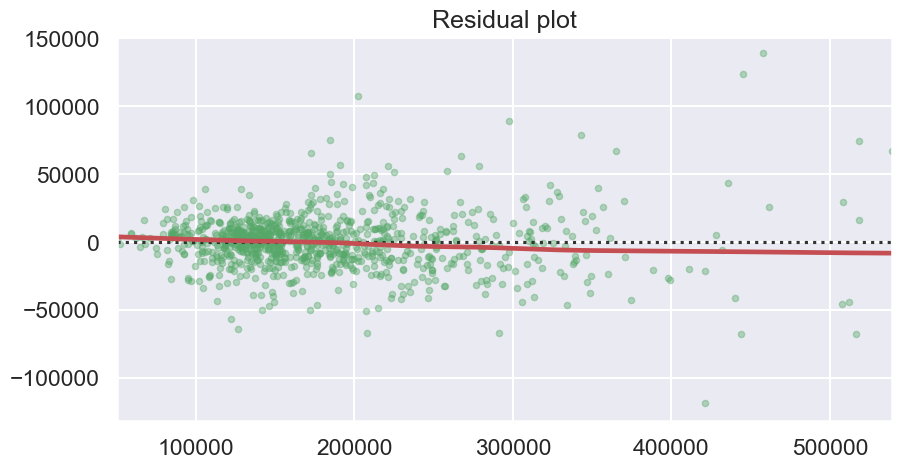

In [325]:
plt.figure(figsize=(10,5))
sns.residplot(x=forest_cv.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

# 3. Gradient boosting

Gradient boosting is one of the most powerful techniques for learning an ensemble of decision trees. In order to get the best performance, some important hyper-parameters need to be carefully tuned.

 - **Number of trees.** This parameter controls the ensemble size. In general, you want the number of trees to be as high as possible (>1000), but having it too high could lead to overfitting. It is usually set via early stopping.
 
 - **Learning rate.** This parameter scales the effect of each tree on the overall prediction. It is tightly coupled with the ensemble size: a smaller value of the learning rate will require a larger number of trees, and vice versa. Typically, a much better generalization error is obtained with small values (<0.1).
 
 - **Maximum tree depth**. This parameter controls the tree dept. Good values for it are generally between 1-10.
 
 - **Row & column subsampling**. These parameters allow to perform a random subsampling of observations and features (like random forests). Tipical values are between 0.5 and 1.
 
 - **L1 & L2 regularization**. These parameters allow to add a penalization on the weights used to combine the trees into the final prediction. Big values will make the model more conservative.

There are several other hyper-parameters. You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html#sklearn.ensemble.GradientBoostingRegressor) for the full list. 

## 3.1 Regression model

You'll use the model `GradientBoostingRegressor` implemented by Scikit-Learn. Even with the default hyper-parameters, gradient boosting performs on par with baseline models. Let's see if we can do better by tuning the hyper-parameters.

In [326]:
# model
boost = GradientBoostingRegressor(n_estimators=500, random_state=42)

# train
boost.fit(X_train, y_train)

# test
score = boost.score(X_test, y_test)

# show
print('Gradient boosting: {:.4f}'.format(score))

Gradient boosting: 0.9450


## 3.2 Ensemble size

The number of trees in the ensemble is one of the hyper-parameters that control the tradeoff between **under-fitting** and **over-fitting**. To determine if the ensemble is overfitting, you can analyze the performance on the train and test sets during the learning phase. So doing, you'll be able to monitor how the prediction evolves as we add more trees to the ensemble. 

The Scikit-learn's models `GradientBoostingRegressor` and `GradientBoostingClassifier` keep track of the performance on the train set during the learning process. In addition, they provide a special method called `.staged_fit()` that allows you to do the same on the test set. The following code plots the train and test errors as a function of the number of trees. This is called the **deviance plot**. 

In [327]:
def deviance_plot(model, X_test=None, y_test=None, show=False):
    
    # deviance on the train set
    train_score = np.sqrt(model.train_score_)
    
    # deviance on the test set
    test_score = None
    if X_test is not None:
        test_score = np.zeros(model.n_estimators_)
        for i, y_pred in enumerate(model.staged_predict(X_test)):
            test_score[i] = np.sqrt(model.loss_(y_test, y_pred))

    fig = plt.figure(figsize=(10, 7))
    n_trees = np.arange(model.n_estimators_)
    plt.plot(n_trees + 1, train_score, 'b-', label='Train')
    if test_score is not None:
        plt.plot(n_trees + 1, test_score, 'r-', label='Test')
    
    if show:
        n_est = model.n_estimators_ - 10
        plt.annotate('', xy=(n_est, test_score[n_est]), xytext=(n_est, train_score[n_est]), 
                     arrowprops={'arrowstyle': '<->', 'color': 'k'})
        plt.text(n_est+3, (test_score[n_est+3] + train_score[n_est+3])/2, 'Overfitting', va='center')
        
    plt.legend(loc='upper right')
    plt.xlabel('Number of trees in the ensemble')
    plt.ylabel('Deviance')
    plt.tight_layout()
    plt.show()

You can visualize the deviance plot to quickly recognize if the model overfit the training data.

C:\Users\Franc\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `loss_` was deprecated in version 1.1 and will be removed in 1.3.
  warnings.warn(msg, category=FutureWarning)


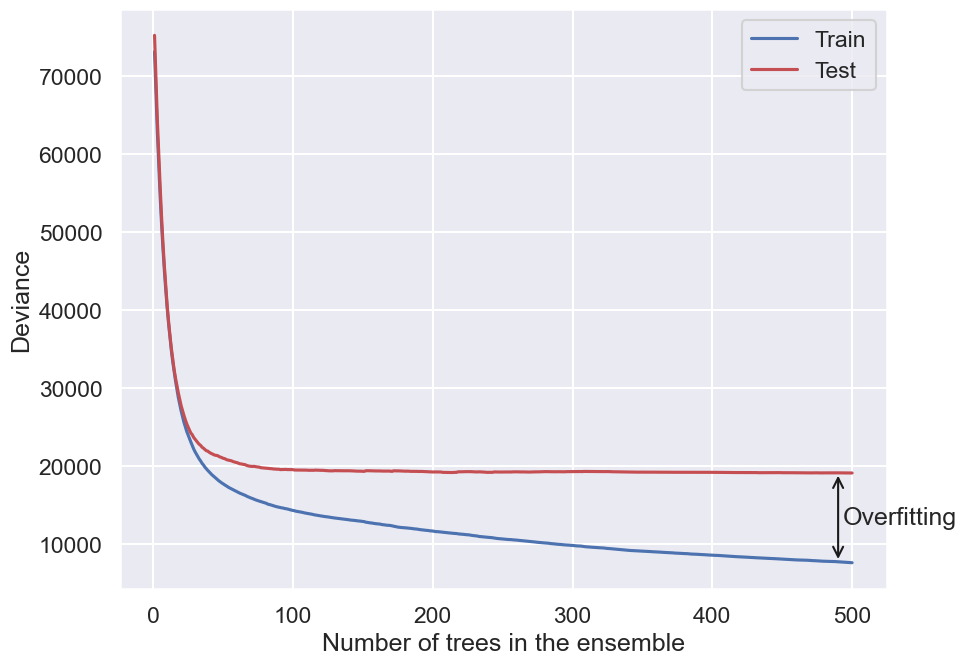

In [328]:
deviance_plot(boost, X_test, y_test, show=True)

You can see that there is a **gap** between the train and the test errors. This is a clear sign that the model is **overfitting**. Indeed, after you add many trees to the ensemble, the model gets too much capacity (i.e., high variance) and starts fitting the idiosyncracies of the training data.

Fortunately, gradient boosting provides some knobs to reduce overfitting:
 - Early stopping
 - Tree-depth control
 - Random subsampling
 - Regularization 

## 3.3 Early stopping

One of the possible ways to fight overfitting is **early stopping**. The idea behind it is to stop the training when the model begins to overfit. In practice, the training can be stopped when no improvement is observed on the validation error after a fixed number of epochs. 

To activate the early stopping, you need to set the following hyper-parameter when the model is defined:
 - `n_iter_no_change` - The number of epochs over which no improvement must be observed in order to stop.

Additional, you can control early stopping by changing the following hyper-parameters:
 - `tol` - Tolerance for the early stopping (default = 1e-4).
 - `validation_fraction` - The proportion of training data to set aside as validation set for early stopping. Must be between 0 and 1 (default = 0.1).
 
The code below shows how to activate early stopping. You will notice that the training time is shorter, as the best number of trees is smaller than the original value set in the model declaration.

Gradient boosting (early stop): 0.9395
Best number of trees: 105


C:\Users\Franc\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `loss_` was deprecated in version 1.1 and will be removed in 1.3.
  warnings.warn(msg, category=FutureWarning)


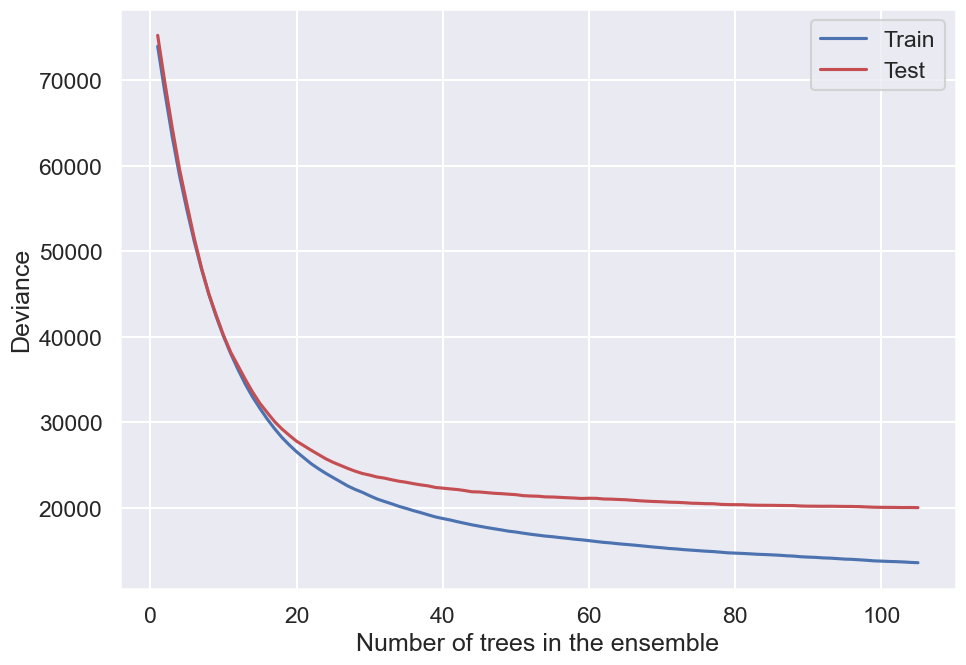

In [329]:
# model (with early stopping)
early_boost = GradientBoostingRegressor(n_estimators=500, n_iter_no_change=10, random_state=42)

# train
early_boost.fit(X_train, y_train)

# test 
boost_score = early_boost.score(X_test, y_test)

# show
print('Gradient boosting (early stop): {:.4f}'.format(boost_score))
print("Best number of trees: " + str(early_boost.n_estimators_))
deviance_plot(early_boost, X_test, y_test)

## 3.4 Tree depth

The hyper-paremeter `max_depth` controls the depth of each individual tree in the ensemble. A big value of `max_depth` increases the variance (i.e., the model tends to over-fit), whereas a small value increases the bias (i.e., the model tends to under-fit). Another way to control the size of each tree is by setting the number of leaf nodes via `max_leaf_node`.

The code below illustrates the effect of this hyper-parameter on the performance. Since `max_depth` has been reduced with respect to the default value, the trained model shows less variance (almost no gap between the train and test curves) but greater bias (the performace is slightly worse).

Gradient boosting (early stop & max depth): 0.9315
Best number of trees: 225


C:\Users\Franc\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `loss_` was deprecated in version 1.1 and will be removed in 1.3.
  warnings.warn(msg, category=FutureWarning)


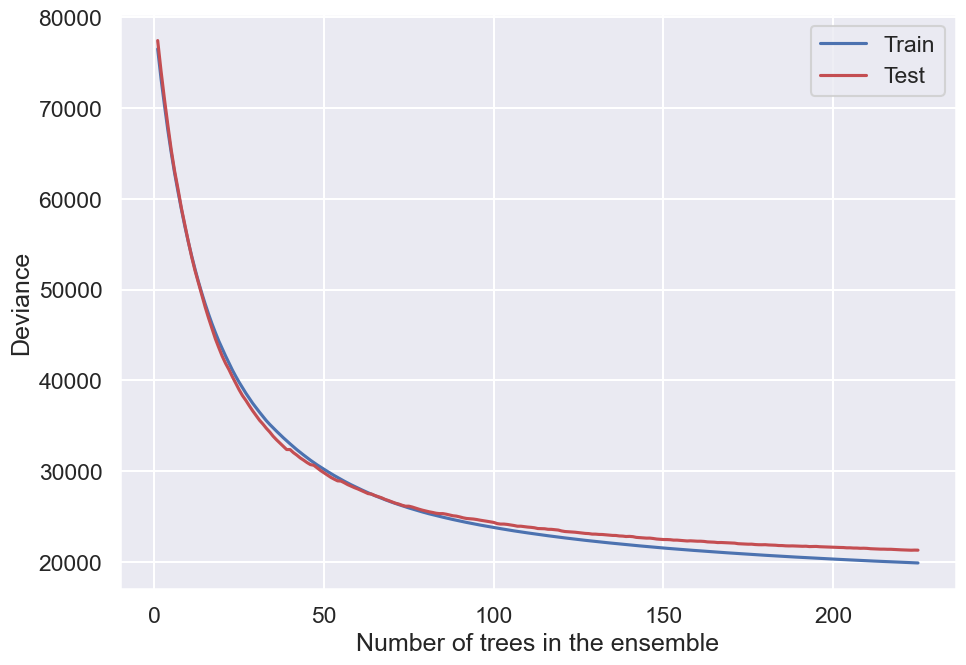

In [330]:
# model (with early stopping & modified 'max_depth')
depth_boost = GradientBoostingRegressor(n_estimators=500, n_iter_no_change=10, max_depth=1, random_state=42)

# train
depth_boost.fit(X_train, y_train)

# test 
boost_score = depth_boost.score(X_test, y_test)

print('Gradient boosting (early stop & max depth): {:.4f}'.format(boost_score))
print("Best number of trees: " + str(depth_boost.n_estimators_))

# show
deviance_plot(depth_boost, X_test, y_test)

## 3.5 Learning rate

The hyper-parameter `learning_rate` scales the effect of each tree on the overall prediction. It is tightly coupled with the hyper-parameter `n_estimators` (ensemble size). A smaller value of `learning_rate` allows the ensemble to generalize better to new unseen data, but it requires a higher value of `n_estimators` to get good results. However, if the latter is too high, the model starts to overfit.

The code below illustrates the effect of this hyper-parameter on the performance. Since `learning_rate` has been increased with respect to the default value, the trained model shows greater variance (large gap between the train and test curves), which makes the performace worse.

Gradient boosting (early stop & learning rate): 0.9267
Best number of trees: 71


C:\Users\Franc\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `loss_` was deprecated in version 1.1 and will be removed in 1.3.
  warnings.warn(msg, category=FutureWarning)


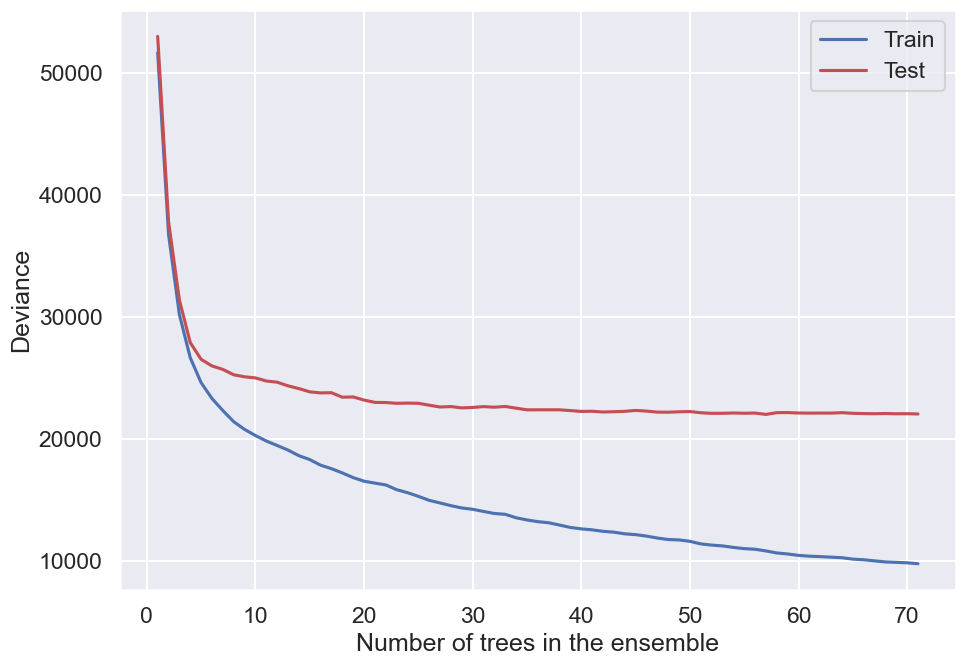

In [331]:
# model (with early stopping & modified 'learning_rate')
lr_boost = GradientBoostingRegressor(n_estimators=500, n_iter_no_change=10, learning_rate=0.5, random_state=42)

# train
lr_boost.fit(X_train, y_train)

# test 
boost_score = lr_boost.score(X_test, y_test)

print('Gradient boosting (early stop & learning rate): {:.4f}'.format(boost_score))
print("Best number of trees: " + str(lr_boost.n_estimators_))

# show
deviance_plot(lr_boost, X_test, y_test)

## 3.5 Random subsampling

The training of each individual tree in the ensemble can be controlled by three hyper-parameters.
 - `subsample` - The fraction of samples to be used for fitting the individual trees. This allows you to combine gradient boosting with bootstrap averaging (bagging), leading to a reduction of variance and an increase in bias.
 - `max_features` - The number of features to consider when looking for the best split. This is another strategy to reduce the variance by subsampling the features analogous to random forestC.
   
Note that `subsample` interacts with other hyper-parameters. When you set `subsample`, you should also lower `learning_rate` and increase `n_estimators`.  As a rule of thumb, a good value of `max_features` could be the square root of the total number of features. Also, keep in mind that feature sampling works better if there is a sufficient large number of features.

The code below illustrates the effect of these hyper-parameters on the performance.

Gradient boosting (early stop & random): 0.9412
Best number of trees: 138


C:\Users\Franc\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:103: FutureWarning: Attribute `loss_` was deprecated in version 1.1 and will be removed in 1.3.
  warnings.warn(msg, category=FutureWarning)


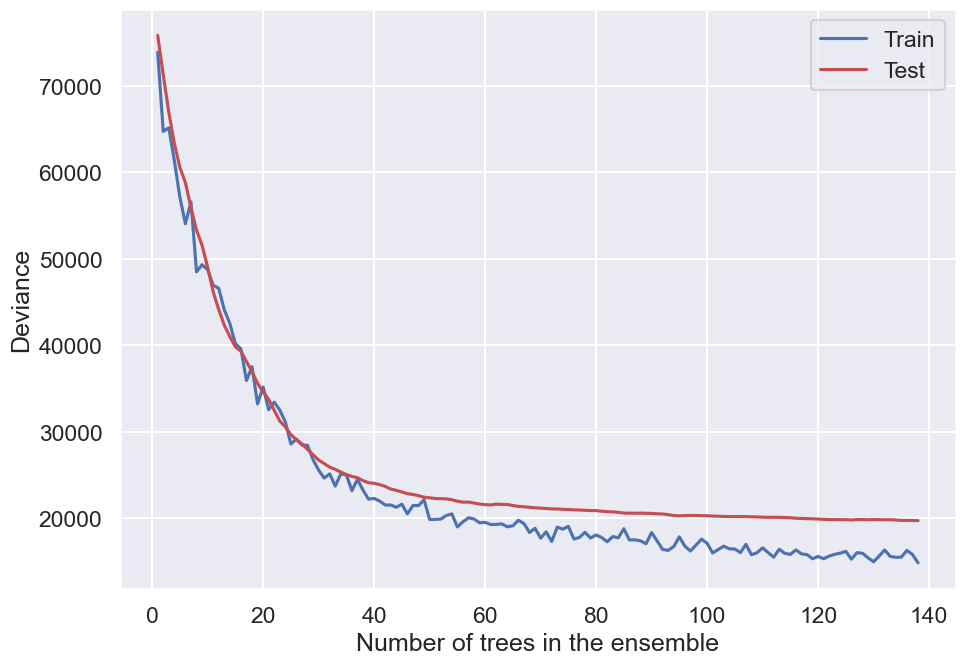

In [333]:
# model (early stopping & random subsampling)
random_boost = GradientBoostingRegressor(n_estimators=500, n_iter_no_change=10, 
                                         subsample=0.5, max_features='sqrt', random_state=42)

# train
random_boost.fit(X_train, y_train)

# test 
boost_score = random_boost.score(X_test, y_test)

print('Gradient boosting (early stop & random): {:.4f}'.format(boost_score))
print("Best number of trees: " + str(random_boost.n_estimators_))

# show
deviance_plot(random_boost, X_test, y_test)

## 3.6 Hyper-parameter tuning


To obtain the best performance, you have to set hyper-parameters via cross-validation. Here is a good recipe:
 - Pick `n_estimators` as large as possible.
 - Activate early stopping.
 - Use cross-validation on `max_depth`, `learning_rate`, `subsample`, `max_features`.
 - Retrain with the best hyper-parameters (and early stopping).

### Exercise

> **Find the best-hyperparameters via cross-validation. You are only allowed to use the train set.**
 
*Hint:*
 - You may find useful the Scikit-Learn class `GridSearchCV`.
 - The following table reports the values that are typically tested out with cross-validation 
 
| Hyper-parameter | Values |
|---|---|
| n_estimators | 1000 |
| n_iter_no_change | 10 |
| learning_rate| 0.001, 0.01, 0.1 |
| max_depth | 1, 2, 3 |
| subsample | 0.4, 0.5, 0.6 |
| max_features | 0.3, 0.4, 0.5 |

- To save time, you can adopt a *coarse-to-fine* approach.

In [334]:
### YOUR CODE HERE ###
paramGrid = { 
    "n_estimators": [1000], 
    "n_iter_no_change": [10],
    "learning_rate": [0.001, 0.01, 0.1],
    "max_depth": [1, 2, 3],
    "subsample": [0.4, 0.5, 0.6],
    "max_features": [0.3, 0.4, 0.5]
    
    # "hyper-parameter name": [value1, values2, ...],
    # "hyper-parameter name": [value1, values2, ...],
    # "hyper-parameter name": [value1, values2, ...],
}


# model
boost = GradientBoostingRegressor(random_state=42)

# cross-validation strategy
cv = KFold(n_splits=5)

# hyper-parameter search
gridsearch = GridSearchCV(boost, paramGrid, cv=cv, verbose=True, n_jobs=4)
gridsearch.fit(X_train, y_train)

print('---')
print('Best hyperparameters:\n' + str(gridsearch.best_params_))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
---
Best hyperparameters:
{'learning_rate': 0.01, 'max_depth': 3, 'max_features': 0.4, 'n_estimators': 1000, 'n_iter_no_change': 10, 'subsample': 0.5}


In [335]:
# If this cell raises an error, your solution is *NOT* correct

assert gridsearch.best_params_['learning_rate'] == 0.01
assert gridsearch.best_params_['max_depth'] == 3
assert gridsearch.best_params_['max_features'] == 0.4
assert gridsearch.best_params_['subsample'] == 0.5

You can now retrain the ensemble using the best hyper-parameters.

In [342]:
# model
boost = GradientBoostingRegressor(**gridsearch.best_params_)

# train
boost.fit(X_train, y_train)

# test
score = boost.score(X_test, y_test)

# print
print('Gradient boosting: {:.4f} (with {:d} trees)'.format(score, boost.n_estimators_))

Gradient boosting: 0.9453 (with 836 trees)


Let's also check the residual plot.

Text(0.5, 1.0, 'Residual plot')

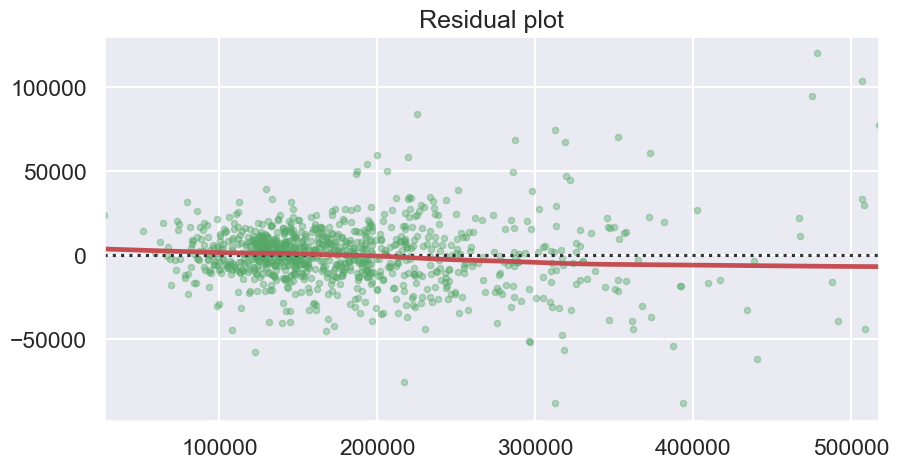

In [343]:
plt.figure(figsize=(10,5))
sns.residplot(x=boost.predict(X_test), y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})

plt.title("Residual plot")

# 4. Stacking

Stacked generalization is a way of combining multiple models through the concept of a meta learner. The general procedure is as follows:
- **Base models.** Several models are trained to generate an intermediate set of features (e.g., their predictions).
- **Meta learner.** A separate model is then trained to combine the intermediate features into the final prediction.

The tricky part is figuring out how to train the meta learner. Here's how it could be done.
1. Split the train set into two disjoint sets.
2. Train the base models on the first part.
3. Use them to generate the intermediate predictions on the second part.
4. Train the meta-learner using the intermediate predictions as the inputs, and the correct responses as the outputs.

The above procedure is practically the same as **hold-out** cross-validation, but it is also possible to use the **K-fold** approach (more on this later).

## 4.1 Stacked average

To gain more insight into the matter, let's begin with a simplified form of stacking, where the meta learner is just the average of the intermediate predictions. The following code illustrates how use the `VotingRegressor`implemented by Scikit-Learn. A voting regressor is an ensemble meta-learner that fits several base regressors, each on the whole dataset. Then it averages the individual predictions to form a final prediction. You can see that such a simple form of stacking performs better than the base models.

In [344]:
# base models
models = [
    ('Linear regression', log_target(LinearRegression())),
    ('Ridge regression', make_pipeline(RobustScaler(), log_target(Ridge(alpha=20)))),
    ('Lasso regression', make_pipeline(RobustScaler(), log_target(Lasso(alpha=0.0005, random_state=42)))),
    ('Elastic net', make_pipeline(RobustScaler(), log_target(ElasticNet(alpha=0.001, l1_ratio=0.40, random_state=42)))),
    ('Random forest', RandomForestRegressor(n_estimators=80, max_features=0.4, random_state=42)),
    ('Boosting', GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, max_depth=3, subsample=0.5, max_features=0.4, random_state=42))
]

# ensemble
stacked_average = VotingRegressor(models)

# performance
for name, single in models + [('Stacked average', stacked_average)]:
    
    # train
    single.fit(X_train, y_train)
    
    # test
    score = single.score(X_test, y_test)
    
    # show
    print( "{:<20}{:.4f}".format(name, score) )

Linear regression   0.9403
Ridge regression    0.9464
Lasso regression    0.9452
Elastic net         0.9456
Random forest       0.9350
Boosting            0.9483
Stacked average     0.9521


### Exercise

> **Implement your own version of "Average Stacking".**

*Hints:*
- Training is a loop where you call the method `.fit()` on each model in `base_models`.
- Prediction is a loop where you call the method `.predict()` on each model in `base_models` and compute the average.

In [218]:
class AverageStacking:
    
    def __init__(self, base_models):
        self.base_models = base_models
    
    def fit(self, X, y):

        # Train the base models
        for name, model in self.base_models:
            ... # YOUR CODE HERE

    def predict(self, X):
        
        # Average the prediction of all the base models  the intermediate features
        y = 0
        for name, model in self.base_models:
            y = None # YOUR CODE HERE
        
        return y

In [220]:
# If this cell raises an error, your solution is *NOT* correct

avg_stack = AverageStacking(models)
avg_stack.fit(X_train, y_train)
y_pred = avg_stack.predict(X_test)
avg_score = r2_score(y_test, y_pred)

np.testing.assert_almost_equal(avg_score, 0.9521, decimal=3)

## 4.2 Stacking

Stacked generalization consists in stacking the output of base models, and use a meta-learner to compute the final prediction. Stacking leverages the strength of each individual estimator by using their output as input of a final estimator. More specifically, stacking works as follows.
 - Divide the training data into K different folds. 
 - Train the base models using K-1 folds, and use them to make intermediate predictions from the unused fold. 
 - Repeat the process by holding out a different fold, and continue until you have generated the intermediate predictions for all the K folds.
 - Use all the training data to train the base models, and all the intermediate predictions to train the meta learner.
 - On new data, use the base models to generate the intermediate predictions, and feed them to the meta learner.

Stacking is implemented in Scikit-Learn by the models `StackingRegressor` and `StackingClassifier`. The code below shows how use them.

In [241]:
# ensemble = base models + meta-learner
stacking = StackingRegressor(models)

# train
stacking.fit(X_train, y_train)

# test
score = stacking.score(X_test, y_test)

# show
print('K-fold stacking: {:.4f}'.format(score))

### Exercise 

> **Implement your own version of "K-Fold Stacking".**

*Hint:* You can implement a class wrapping the base models and the meta learner into a single ensemble. The class has the following attributes and methods:
 - `base_models` - a list of scikit-learn models.
 - `meta_learner` - a single scikit-learn model.
 - `fit(X, y)` - Train the base models and the meta learner (see above).
 - `predict(X)` - Predict on new data (see above).
 
You can use the scikit-learn function `cross_val_predict()` to generate the intermediate predictions.

In [245]:
class KFoldStacking:
    
    def __init__(self, base_models, meta_learner):
        self.base_models = base_models
        self.meta_learner = meta_learner
    
    
    def fit(self, X, y):
        
        # Train the base models
        X_meta = np.zeros((X.shape[0], len(self.base_models)))
        for i, (name, model) in enumerate(self.base_models):
            
            # Use 'model' to generate cross-validated predictions
            ... # YOUR CODE HERE
            
            # Train 'model' on the whole training set
            ... # YOUR CODE HERE
        
        # Train the meta-learner on the generates predictions
        ... # YOUR CODE HERE
        
    
    def predict(self, X):
        
        X_meta = []
        
        for name, model in self.base_models:
            
            # Use 'model' to generate predictions 
            y_preds = None # YOUR CODE HERE
            
            X_meta.append(y_preds)
            
        # Stack the intermediate predictions into a matrix
        X_meta = np.column_stack(X_meta)
        
        # Use 'meta_learner' to compute the final predictions
        y = None # YOUR CODE HERE
        
        return y

In [246]:
# If this cell raises an error, your solution is *NOT* correct

stack = KFoldStacking(models, meta_learner=LinearRegression())
stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)
score = r2_score(y_test, y_pred)

np.testing.assert_almost_equal(score, 0.9525, decimal=3)

## 4.3 Power stacking

You have seen that stacking is slightly better than a simple average. However, there is still one thing that can be improved in our implementation. Remark that we train K different versions of the same base model to generate the intermediate features. This is how K-fold cross-validation works. However, we throw them away in the current implementation. Instead, we could make a better use of those models. Let's see how to do so.

This variant of stacking works as follow:
 - Divide the training data into K different folds. 
 - Train the base models using K-1 folds, and use them to make intermediate predictions on the unused fold. 
 - Repeat the process by holding out a different fold, and continue until you have ended up training K different versions of each base model, each of which generates the intermediate predictions for one of the K folds. 
 - Use the intermediate predictions to train the meta learner.
 - On new data, use the K ensembles of base models to generate K different sets of intermediate predictions, and average them together to get a single set, and feed it to the meta learner.
 
The implementation is provided below. Study the code annd compare it to the implementation of K-Fold Stacking.

In [249]:
class PowerStacking:
    
    def __init__(self, base_models, meta_learner):
        self.base_models = base_models
        self.meta_learner = meta_learner
    
    
    def fit(self, X, y):
        
        # 1. Initialize
        cv = KFold(n_splits=5)
        models = self.base_models
        self.base_models = [list() for x in models]
        
        # 2. Train the base models
        X_meta = np.zeros((X.shape[0], len(models)))
        for i, (name, model) in enumerate(models):
            for train_idx, valid_idx in cv.split(X, y):
                instance = clone(model)
                self.base_models[i].append(instance)
                instance.fit(X[train_idx,:], y[train_idx])
                X_meta[valid_idx, i] = instance.predict(X[valid_idx,:])
        
        # 3. Train the meta learner
        self.meta_learner.fit(X_meta, y)

        
    def predict(self, X):
        
        # 1. Generate the intermediate features
        X_meta = np.zeros((X.shape[0], len(self.base_models)))
        for i, base_models in enumerate(self.base_models):
            y_stacked = np.column_stack([model.predict(X) for model in base_models])
            X_meta[:,i] = np.mean(y_stacked, axis=1)
                    
        # 2. Return the final predictions
        return self.meta_learner.predict(X_meta)

In [253]:
# stacking
stack = PowerStacking(models, meta_learner=LinearRegression())

# train
stack.fit(X_train, y_train)

# test
y_pred = stack.predict(X_test)

# evaluate
score = r2_score(y_test, y_pred)

# show
print('Power stacking: {:2.4f}'.format(score))

You can see that the performance has slightly improved. Let's also check the residual plot.

In [254]:
plt.figure(figsize=(10,5))
sns.residplot(x=y_pred, y=y_test, lowess=True, color="r", scatter_kws={"color":"g", "s":20, "alpha": 0.4})
plt.title("Residual plot")
plt.show()

The take-away message is that stacking is a powerful machine learning technique. Sometimes, it may be superior to the performance of neural networks, which are nowadays considered the state of the art in supervised learning. When you deal with tabular data, stacking should be the first thing to try.